# C1 — Direct Multi-Step XGBoost / HGB — **Perfect Weather + HYSPLIT Forecast**

## Executive Summary
Identical to `B1_baseline_xgboost_perfect_forecast.ipynb` **except** HYSPLIT
features are also shifted to t+h alongside the meteorological columns.

**Weather mode:** `"perfect_forecast_full"` — both MET_COLS and HYSPLIT_NUMERIC
and HYSPLIT_CATEGORICAL are shifted by `-h`. Row t carries:
- Weather at t+h (NWP forecast)
- Air-mass trajectory at t+h (HYSPLIT trajectory forecast)
- PM2.5 lags / rolling stats / neighbor lags still at t or before (unchanged)

**Series comparison:**
- A-series: weather at t, HYSPLIT at t (current observations)
- B-series: weather at t+h, HYSPLIT at t
- C-series: weather at t+h, HYSPLIT at t+h ← this notebook

**Expected effect:** Additional improvement over B-series at longer horizons
where air-mass origin at t+h differs substantially from origin at t.

In [5]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from src.config import (
    DATA_PATH, TARGET, HORIZONS, N_OPTUNA_TRIALS,
    MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, WEATHER_MODE_PERFECT_FULL
from src.models.baseline_gbm import train_direct_multistep
from src.evaluation import compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted, shap_analysis, comparison_table
from src.utils import ensure_dirs, set_seed

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL   # ← only difference from B1

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print(f'Weather mode: {WEATHER_MODE}')

Weather mode: perfect_forecast_full


## 1. Load and Split Data

In [6]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)
print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')

13:56:46 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
13:56:46 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
13:56:46 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
13:56:46 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
13:56:46 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 rows | Test: 8,784 rows


## 2. Feature Matrix Preview (h=24)
Met columns AND HYSPLIT at t+24; PM2.5 lags / neighbors still at t.

In [7]:
X_preview, y_preview = build_feature_matrix(train_df, horizon=24, weather_mode=WEATHER_MODE)
print(f'Feature matrix shape: {X_preview.shape}')
print(f'Feature names ({len(X_preview.columns)}):')
for i, col in enumerate(X_preview.columns):
    print(f'  {i:2d}. {col}')

13:56:46 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast_full
13:56:46 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
13:56:46 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
13:56:46 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
13:56:46 | src.feature_engineering | INFO |   X: (38057, 45) | y mean=17.38, y std=12.67


Feature matrix shape: (38057, 45)
Feature names (45):
   0. TEMP
   1. WIND_SPEED
   2. PRESS_SEA
   3. HUMIDITY
   4. DEW_POINT
   5. RAIN_6H
   6. SUNSHINE
   7. blh
   8. lon_48
   9. lat_48
  10. dist_48_straight
  11. dist_48_total
  12. ratio_48
  13. lon_24
  14. lat_24
  15. dist_24_straight
  16. dist_24_total
  17. ratio_24
  18. hour_sin
  19. hour_cos
  20. month_sin
  21. month_cos
  22. day_sin
  23. day_cos
  24. is_weekend
  25. pm25_now
  26. pm25_lag_24h
  27. pm25_lag_48h
  28. rolling_mean_24h
  29. rolling_max_24h
  30. trend_24h
  31. MzOtwoBrzozo_lag1h
  32. MzWarWokalna_lag1h
  33. MzWarAlNiepo_lag1h
  34. MzLegZegrzyn_lag1h
  35. MzPiasPulask_lag1h
  36. MzWarBajkowa_lag1h
  37. dir_48_L
  38. dir_48_N
  39. dir_48_S
  40. dir_48_W
  41. dir_24_L
  42. dir_24_N
  43. dir_24_S
  44. dir_24_W


## 3. Train XGBoost — All 24 Horizons

In [8]:
QUICK_TEST = True  # Set to False for full training
n_trials = 5 if QUICK_TEST else N_OPTUNA_TRIALS

print(f'Training XGBoost [perfect_forecast_full] with n_trials={n_trials} per horizon...')
xgb_models = train_direct_multistep(
    train_df, model_type='xgb', n_trials=n_trials, save_models=True,
    weather_mode=WEATHER_MODE
)
print('XGBoost training complete.')

13:56:46 | src.models.baseline_gbm | INFO | ============================================================
13:56:46 | src.models.baseline_gbm | INFO | Direct multi-step training: XGB | 24 horizons | 5 Optuna trials each | weather=perfect_forecast_full
13:56:46 | src.models.baseline_gbm | INFO | ============================================================
13:56:46 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...
13:56:46 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
13:56:46 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
13:56:46 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
13:56:46 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
13:56:46 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69


Training XGBoost [perfect_forecast_full] with n_trials=5 per horizon...


13:56:46 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
13:56:46 | src.models.baseline_gbm | INFO |   Optuna search: XGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit
13:57:07 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8881
13:57:21 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8881
13:57:25 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8881
13:57:30 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8881
13:57:34 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8400
13:57:34 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8400 in 48s | params={'learning_rate': 0.04446862319918233, 'n_estimators': 141, 'max_depth': 6, 'min_child_weight': 12, 'reg_lambda': 0.06505159298527952, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237}
13:57:35 | src.models.baseline_gbm | INFO | [1/24] h=1 done in 49s | elapsed=49

XGBoost training complete.


## 4. Train HistGradientBoosting — All 24 Horizons

In [9]:
print(f'Training HGB [perfect_forecast_full] with n_trials={n_trials} per horizon...')
hgb_models = train_direct_multistep(
    train_df, model_type='hgb', n_trials=n_trials, save_models=True,
    weather_mode=WEATHER_MODE
)
print('HGB training complete.')

14:19:21 | src.models.baseline_gbm | INFO | ============================================================
14:19:21 | src.models.baseline_gbm | INFO | Direct multi-step training: HGB | 24 horizons | 5 Optuna trials each | weather=perfect_forecast_full
14:19:21 | src.models.baseline_gbm | INFO | ============================================================
14:19:21 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...
14:19:21 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
14:19:21 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h


Training HGB [perfect_forecast_full] with n_trials=5 per horizon...


14:19:21 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:19:21 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:19:21 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
14:19:21 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
14:19:21 | src.models.baseline_gbm | INFO |   Optuna search: HGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit
14:19:39 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8790
14:20:10 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8317
14:20:13 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8317
14:20:24 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8317
14:20:35 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8317
14:20:35 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8317 in 74s | params

HGB training complete.


## 5. Evaluate on Test Set (2024)

In [10]:
results = {'XGBoost_full': {}, 'HGB_full': {}}

for h in tqdm(HORIZONS, desc='Evaluating horizons'):
    X_test_h, y_test_h = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)
    results['XGBoost_full'][h] = compute_metrics(y_test_h.values, xgb_models[h].predict(X_test_h.values))
    results['HGB_full'][h]     = compute_metrics(y_test_h.values, hgb_models[h].predict(X_test_h.values))

print('Evaluation complete.')
for model_name in results:
    print(f'\n{model_name}:')
    for h in [1, 6, 12, 24]:
        m = results[model_name][h]
        print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

Evaluating horizons:   0%|          | 0/24 [00:00<?, ?it/s]

14:55:58 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
14:55:58 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
14:55:58 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:55:58 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:55:58 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
14:55:58 | src.feature_engineering | INFO | build_feature_matrix | horizon=2 | weather_mode=perfect_forecast_full
14:55:58 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -2 h
14:55:58 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:55:58 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:55:58 | src.feature_engineering | INFO |

Evaluation complete.

XGBoost_full:
  h= 1: MAE=1.136  RMSE=1.838  R²=0.952
  h= 6: MAE=3.175  RMSE=4.604  R²=0.698
  h=12: MAE=3.972  RMSE=5.666  R²=0.542
  h=24: MAE=4.391  RMSE=6.237  R²=0.448

HGB_full:
  h= 1: MAE=1.132  RMSE=1.841  R²=0.952
  h= 6: MAE=3.073  RMSE=4.534  R²=0.707
  h=12: MAE=3.900  RMSE=5.627  R²=0.548
  h=24: MAE=4.334  RMSE=6.110  R²=0.470


## 6. Three-Series Comparison: A1 vs B1 vs C1

14:56:09 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C1_vs_B1_vs_A1_mae.png


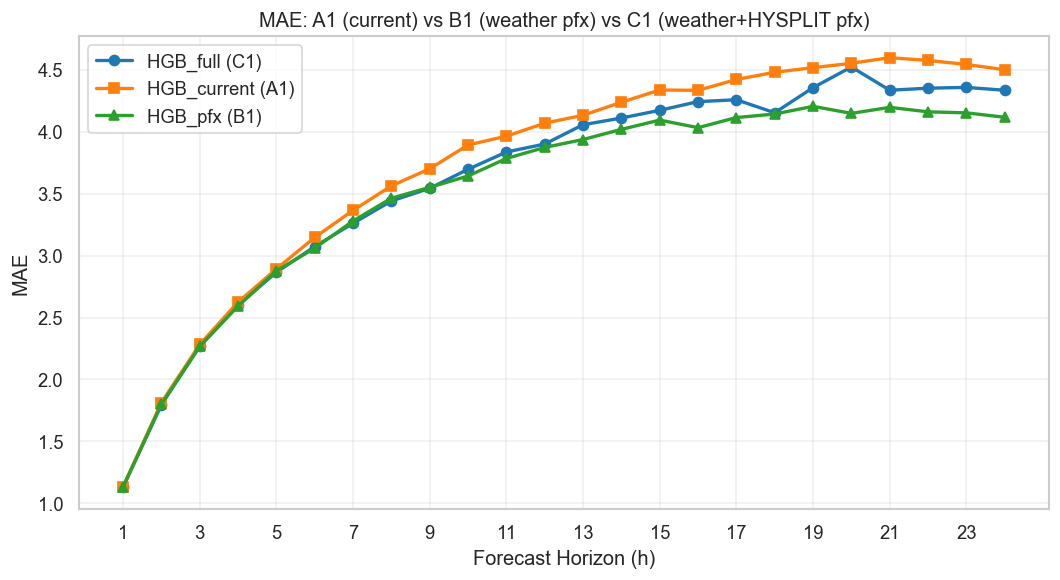

14:56:10 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C1_vs_B1_vs_A1_r2.png


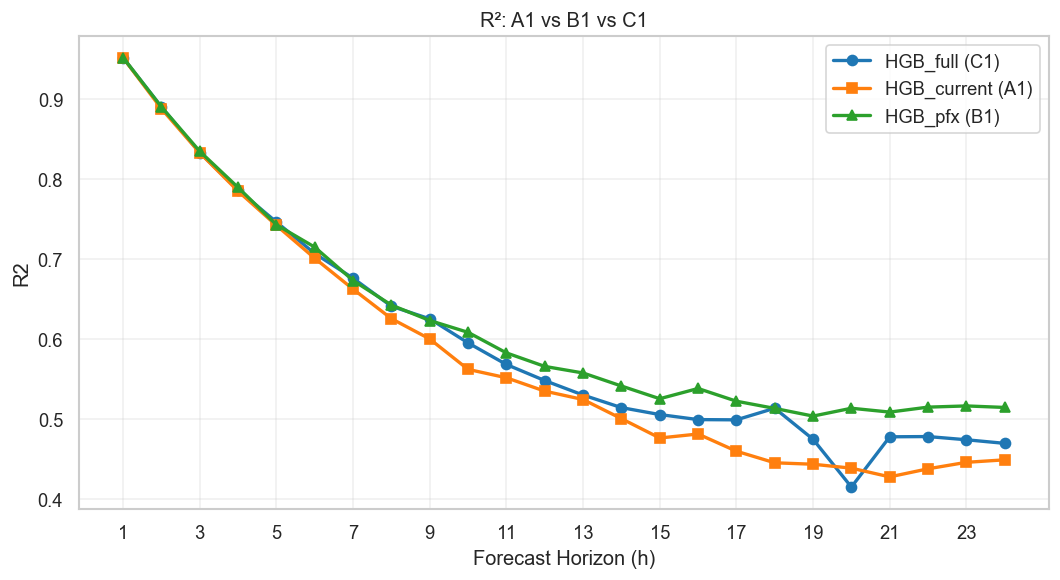

In [11]:
compare = {'HGB_full (C1)': results['HGB_full']}

for fname, model_label, series_label in [
    ('arch1_metrics.csv', 'Arch1_HGB',  'HGB_current (A1)'),
    ('B1_metrics.csv',    'B1_HGB_pfx', 'HGB_pfx (B1)'),
]:
    p = RESULTS_DIR / fname
    if p.exists():
        df_r = pd.read_csv(p)
        sub = df_r[df_r['Model'] == model_label]
        if not sub.empty:
            compare[series_label] = {
                int(r['Horizon']): {'MAE': r['MAE'], 'RMSE': r['RMSE'],
                                    'R2': r['R2'], 'MBE': r['MBE'], 'IA': r['IA']}
                for _, r in sub.iterrows()
            }

fig = plot_horizon_metrics(compare, metric='MAE',
                           save_path=FIGURES_DIR / 'C1_vs_B1_vs_A1_mae.png')
plt.title('MAE: A1 (current) vs B1 (weather pfx) vs C1 (weather+HYSPLIT pfx)')
plt.show()

fig = plot_horizon_metrics(compare, metric='R2',
                           save_path=FIGURES_DIR / 'C1_vs_B1_vs_A1_r2.png')
plt.title('R²: A1 vs B1 vs C1')
plt.show()

## 7. Actual vs Predicted (h=24, Winter 2024)

14:56:10 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast_full
14:56:10 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
14:56:10 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:56:10 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:56:10 | src.feature_engineering | INFO |   X: (7766, 45) | y mean=12.60, y std=8.39


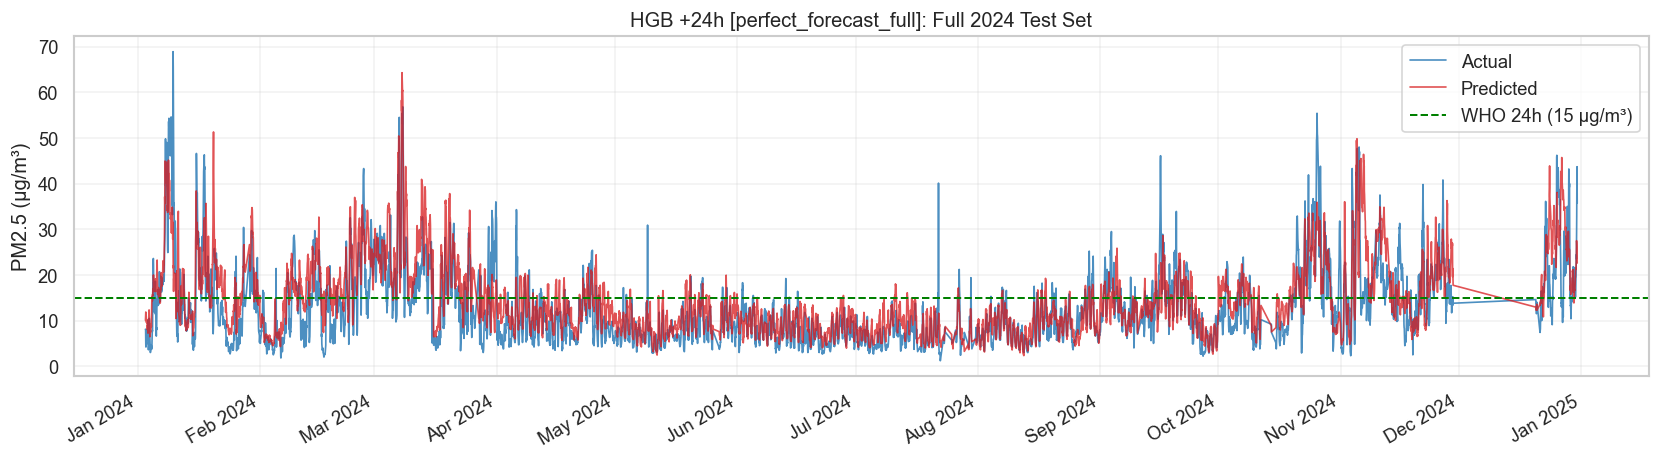

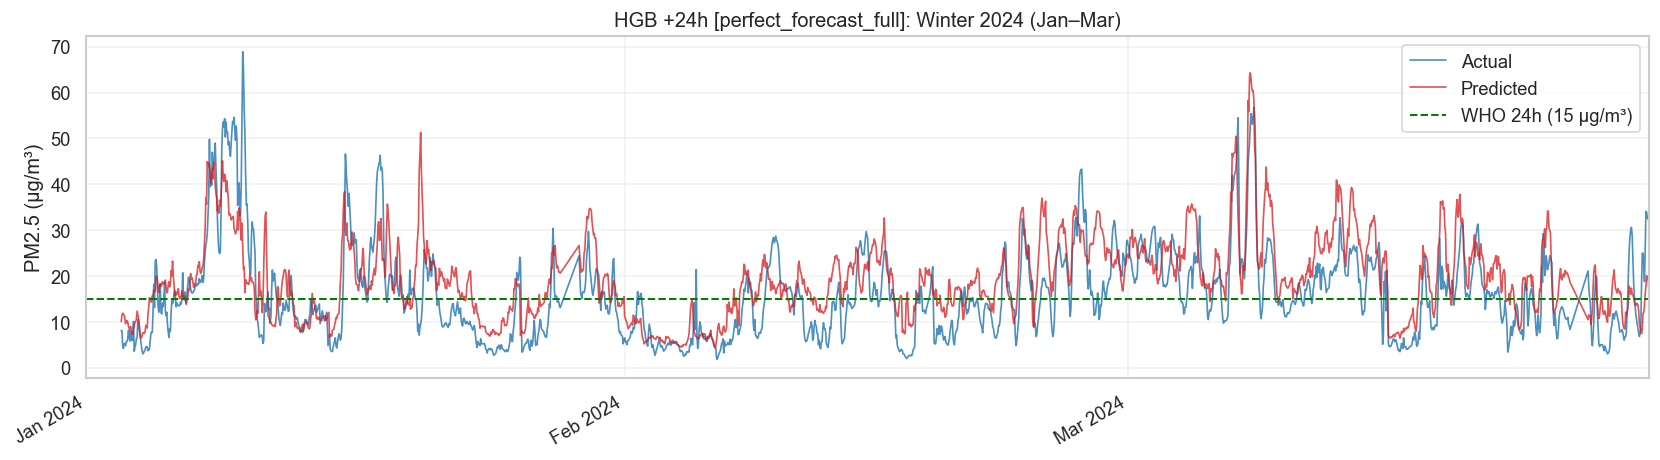

In [12]:
X_test_24, y_test_24 = build_feature_matrix(test_df, horizon=24, weather_mode=WEATHER_MODE)
hgb_pred_24 = hgb_models[24].predict(X_test_24.values)

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h [perfect_forecast_full]: Full 2024 Test Set',
    save_path=FIGURES_DIR / 'C1_hgb_full_2024.png'
)
plt.show()

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h [perfect_forecast_full]: Winter 2024 (Jan–Mar)',
    zoom_period=('2024-01-01', '2024-03-31'),
    save_path=FIGURES_DIR / 'C1_hgb_winter2024.png'
)
plt.show()

## 8. SHAP Feature Importance

In [13]:
for h in [1, 6, 12, 24]:
    X_test_h, _ = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)
    shap_analysis(
        xgb_models[h].regressor_, X_test_h, X_test_h.columns.tolist(),
        save_dir=FIGURES_DIR, title_suffix=f'C1_XGB_h{h}'
    )

14:56:12 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
14:56:12 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
14:56:12 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:56:12 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:56:12 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
14:56:18 | src.evaluation | INFO | SHAP plots saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures
14:56:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=6 | weather_mode=perfect_forecast_full
14:56:18 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -6 h
14:56:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy 

## 9. Save Results

In [14]:
rows = []
for model_name, h_metrics in results.items():
    for h, metrics in h_metrics.items():
        rows.append({'Model': f'C1_{model_name}', 'Horizon': h, **metrics})

pd.DataFrame(rows).to_csv(RESULTS_DIR / 'C1_metrics.csv', index=False)
print('Saved C1_metrics.csv')

tbl = comparison_table({'XGBoost_full': results['XGBoost_full'], 'HGB_full': results['HGB_full']})
print('\nKey horizon comparison (perfect_forecast_full):')
print(tbl.to_string(float_format='%.3f'))

Saved C1_metrics.csv

Key horizon comparison (perfect_forecast_full):
                       MAE  RMSE    R2   MBE    IA
Model        Horizon                              
HGB_full     1       1.132 1.841 0.952 0.044 0.988
             6       3.073 4.534 0.707 0.746 0.916
             12      3.900 5.627 0.548 1.623 0.875
             24      4.334 6.110 0.470 1.917 0.848
XGBoost_full 1       1.136 1.838 0.952 0.046 0.988
             6       3.175 4.604 0.698 1.106 0.916
             12      3.972 5.666 0.542 1.724 0.872
             24      4.391 6.237 0.448 2.110 0.846
